In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## **<center>Ejercicio práctico clase 1</center>**

- Docente: Edwin Jahir Rueda Rojas
- Email: edruedaro@uide.edu.ec

Bienvenidos al componente prático de la semana 1. A parte de las preguntas práticas y teóricas que deberás responder, ten en cuenta lo siguiente:
- Encontrarás enlaces a documentación externa que te ayudará a resolver los ejercicios prácticos.
- Resuelve los ejercicios de forma secuencial, sobrescribiendo el conjunto de datos para obtener los resultados esperados.
- Encontrarás debajo de cada celda un gráfico que te guiará a la respuesta esperada (una vez ejecutada la celda, este desaparecerá)

#**GRUPO 6**
ALEXANDER PAUL LUNA ARTEAGA

CARLOS ANDRES AREVALO TORRES

EDISON MAURICIO PILATASIG CHANATASIG

Recursos útiles para el desarrollo de esta práctica:

Gráficos circulares:
* https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html
* https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.pie.html

Gráficos en seaborn:
https://python-charts.com/es/seaborn/

Gráficar en ejes matplotlib usando seaborn:
https://stackoverflow.com/questions/23969619/plotting-with-seaborn-using-the-matplotlib-object-oriented-interface

Estructura de pandas dataframe aceptada por seaborn: https://seaborn.pydata.org/tutorial/data_structure.html

## Fase 1: Carga y limpieza de datos

### Descargar los datos
- Los datos son descargados desde un repositorio público. Cuenta con 10841 aplicaciones de google playstore y 13 caracteristicas:
    - App: Nombre de la aplicación
    - Categoría: Categoría dentro de google playstore a la cual pertenece la aplicación.
    - Rating: Calificación promedio dada por los usuarios de google playstore
    - Reviews: Total de comentarios de la aplicación.
    - Size: Tamaño de la aplicación en Kb.
    - Installs: Total de instalaciones de la aplicación.
    - Type: si es gratuita o de pago.
    - Price: Precio de la aplicación en dólares.
    - Content Rating: clasificación de la aplicación en base a su contenido.
    - Genres: Géneros dentro de google playsotre a los que pertenece la aplicación.
    - Last Updated: Fecha de la última actualización de la aplicación.
    - Current Ver: Versión actual de la aplicación.
    - Android Ver: Versión de android que soporta la aplicación.

In [2]:
!wget https://github.com/rusheel98/Data-Visualization-on-google-play-store-reviews-dataset/raw/main/googleplaystore_v2.csv

--2026-03-11 01:19:10--  https://github.com/rusheel98/Data-Visualization-on-google-play-store-reviews-dataset/raw/main/googleplaystore_v2.csv
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rusheel98/Data-Visualization-on-google-play-store-reviews-dataset/main/googleplaystore_v2.csv [following]
--2026-03-11 01:19:10--  https://raw.githubusercontent.com/rusheel98/Data-Visualization-on-google-play-store-reviews-dataset/main/googleplaystore_v2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1373288 (1.3M) [text/plain]
Saving to: ‘googleplaystore_v2.csv’

googleplaystore_v2. 100%[===============

### Cargar datos

In [3]:
data = pd.read_csv('./googleplaystore_v2.csv')

data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
data.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000.000000,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3600.000000,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9500.000000,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,21516.529524,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19000.000000,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [5]:
data.shape

(10841, 13)

### Limpieza y manejo de datos preliminares

In [6]:
# eliminar registros con alguna columna vacia
data = data.dropna()
data.shape

(9360, 13)

In [7]:
# corregir los tipos de datos incorrectos para las columnas
data.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,object
Size,float64
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


In [8]:
data["Price"]

,Price
0,0
1,0
2,0
3,0
4,0
...,...
10834,0
10836,0
10837,0
10839,0


In [9]:
data.Price.unique()

array(['0', '$4.99', '$3.99', '$6.99', '$7.99', '$5.99', '$2.99', '$3.49',
       '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49', '$10.00',
       '$24.99', '$11.99', '$79.99', '$16.99', '$14.99', '$29.99',
       '$12.99', '$2.49', '$10.99', '$1.50', '$19.99', '$15.99', '$33.99',
       '$39.99', '$3.95', '$4.49', '$1.70', '$8.99', '$1.49', '$3.88',
       '$399.99', '$17.99', '$400.00', '$3.02', '$1.76', '$4.84', '$4.77',
       '$1.61', '$2.50', '$1.59', '$6.49', '$1.29', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$8.49', '$1.75', '$14.00', '$2.00',
       '$3.08', '$2.59', '$19.40', '$3.90', '$4.59', '$15.46', '$3.04',
       '$13.99', '$4.29', '$3.28', '$4.60', '$1.00', '$2.95', '$2.90',
       '$1.97', '$2.56', '$1.20'], dtype=object)

In [10]:
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700.0,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [11]:
def test(x):
    if x=="0":
        return 0
    else:
        return float(x[1:])

In [12]:
# corregir algunos valores en formato string para que toda la columna sea tipo float
data.Price = data.Price.apply(lambda x: 0 if x=="0" else float(x[1:]))

# cast los datos de los Reviews a tipo entero
data.Reviews = data.Reviews.astype("int32")

# Convertir la columna installs a valores numericos
# ignoramos el +
def clean_installs(val):
    return int(val.replace(",","").replace("+",""))

data.Installs = data.Installs.apply(clean_installs)

# convertir las fechas en string a formato date
data['Last Updated'] = pd.to_datetime(data['Last Updated'])


In [13]:
data.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,int32
Size,float64
Installs,int64
Type,object
Price,float64
Content Rating,object
Genres,object


### Controles de verificación de los datos

Sirve para asegurarnos de que nuestros datos cumplan reglas lógicas presentes en nuestros negocios o proyectos.

En el caso de este proyecto se tiene que:


1.   La valoración está entre 1 y 5 para todas las aplicaciones.
2.   El número de opiniones es menor o igual que el número de instalaciones.
3.   Las aplicaciones gratuitas no deben tener un precio superior a 0.

In [14]:
data.Rating.max()

5.0

In [15]:
# Agregamos bloque TRY para manejar mejor la excepción AssertionError si hay calificaciones superiores a 5
try:
    assert data.Rating.max() <= 5, 'Hay calificaciones superiores a 5'
    print("\n"+"+"*80)
    print("¡Validación exitosa!, NO se tienen calificaciones superiores a 5")
    print("+"*80)
except AssertionError as error:
    print(f"La validación falló: {error}")
    # Mostrar los datos que dieron error
    incorrectos = data[data.Rating > 5]
    print(f"Se encontraron {len(incorrectos)} registros con calificaciones superiores a 5'.")



++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
¡Validación exitosa!, NO se tienen calificaciones superiores a 5
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [16]:
# Agregamos bloque TRY para manejar mejor la excepción AssertionError si hay calificaciones inferiores a 1
try:
    assert data.Rating.min() >= 1, 'Hay calificaciones inferiores a 1'
    print("\n"+"+"*80)
    print("¡Validación exitosa!, NO hay calificaciones inferiores a 1")
    print("+"*80)
except AssertionError as error:
    print(f"La validación falló: {error}")
    # Mostrar los datos que dieron error
    incorrectos2 = data[data.Rating < 1]
    print(f"Se encontraron {len(incorrectos2)} registros con calificaciones inferiores a 1'.")


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
¡Validación exitosa!, NO hay calificaciones inferiores a 1
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [19]:
# Genera aquí el código para cumplir con el check número dos

##### TAREA 1 ###################

#####  2. El número de opiniones es menor o igual que el número de instalaciones.
#Comparar fila a fila si las opiniones son mayores que las instalaciones, obtener el conteo
data_control2=data[data.Reviews > data.Installs]
print("\n"+"+"*80)
print(f"Número de opiniones mayores que el número de instalaciones:    {data_control2.shape[0]}")
#Detallo APPS solo si cumplen condicion
if data_control2.shape[0] > 0:
    print(f"\nDetalle de APPs:\n{data_control2[['App', 'Installs', 'Reviews']]}")
print("+"*80)


#####  3. Las aplicaciones gratuitas no deben tener un precio superior a 0.
# Filtramos donde el Tipo de APP es 'Free' Y el Precio es mayor a 0
data_control3 = data[(data['Type'] == 'Free') & (data['Price'] > 0)]
print("\n"+"+"*80)
print(f"Número de APPs GRATIS con precio mayor a cero ($):    {data_control3.shape[0]}")
#Detallo APPS solo si cumplen condicion
if data_control3.shape[0] > 0:
    print(f"\nDetalle de APPs:\n{data_control3['App']}")
print("+"*80)

#################################


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Número de opiniones mayores que el número de instalaciones:    7

Detalle de APPs:
                                 App  Installs  Reviews
2454             KBA-EZ Health Guide         1        4
4663   Alarmy (Sleep If U Can) - Pro     10000    10249
5917                        Ra Ga Ba         1        2
6700                Brick Breaker BR         5        7
7402            Trovami se ci riesci        10       11
8591                         DN Blog        10       20
10697                        Mu.F.O.         1        2
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Número de APPs GRATIS con precio mayor a cero ($):    0
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


Se verificó que la única anomalía en el dataset son 7 aplicaciones con mayor número de Reviews que de Instalaciones. Como se puede observar en la celda anterior, no supone un problema mayor puesto que tampoco están tan desproporcionadas. Sería un inconveniente de las reglas de negocio EN CASO de que NO se pueda dar reviews sin antes haber instalado.

### Haciendo uso de la visualización para eliminar Outliers o valores atípicos

Es recomendable eliminar los valores extremos en nuestros datos para evitar
sesgos en los respectivos análisis y perspectivas erradas. Aquí podemos hacer
uso de los gráficos de visualización vistos en clase para identificar estos
valores.

**Pregunta 1.** Qué gráfico es adecuado para revisar los valores atípicos de la variable
`Price`?

  RTA:

  - En este caso consideramos que el gráfico Histplot con KDA


**Pregunta 2.** Porqué consideran que el gráfico seleccionado permite identificar outliers?

  RTA:

  - Porque nos permite visualizar de mejor manera cómo se agrupan los outliers (al menos en este caso), siendo mayormente de 0 a 50 USD. Mientras se tienen 17 outliers y 15 de ellos están entre 300 a 400; esto intentamos corroborar con el gráfico de BoxPlot pero como la mayoría de las aplicaciones son gratis, visualmente no se observan las cajas (entonces no se observa tan adecuado). Usando Stripplot se observan las acumulaciones de precios entre 0 a 50 USD (que también puede ser útil, pero si se presentan más datos no va a ser visualmente tan óptimo), y usando histplot con KDE se observa la curva suavizada normal concentrada en 0 USD (que consideramos sería la mejor opción).Por lo que para este caso la gráfica de histplot con KDE nos permite observar que la concentración de precios es en torno a los 0 USD, es decir se tiene demasiadas APPS gratis.






**Nota: Para responder la pregunta 3, primero filtra los datos dejando únicamente las aplicaciones de pago**

**Pregunta 3.** Para fines del componente práctico, consideraremos que todos los datos por debajo o encima de los límites inferiores o superiores del rango intercuartílico serán considerados outliers. Elimina estos datos. ¿Cúantos registros eran? (Considera solo la variable `Price`)

RTA: Fueron 89 outliers que sobrepasaron el valor superior del rango intercuartilico de la variable PRICE. Se redujeron de 9360 a 9271 registros.

Nota: Supondremos un rango intercuartílico leve, donde el extremo inferior está dado por:
$$Q_1-1.5*IQR$$
y el extremo superior por:
$$Q_3 + 1.5*IQR$$

donde $$IQR=Q_3-Q_1$$


**Nota:** Puedes usar Matplotlib, seaborn o pandas plotting

**hint:** Usar gráficos que me permitan revisar distribuciones

(-30.0, 420.0)

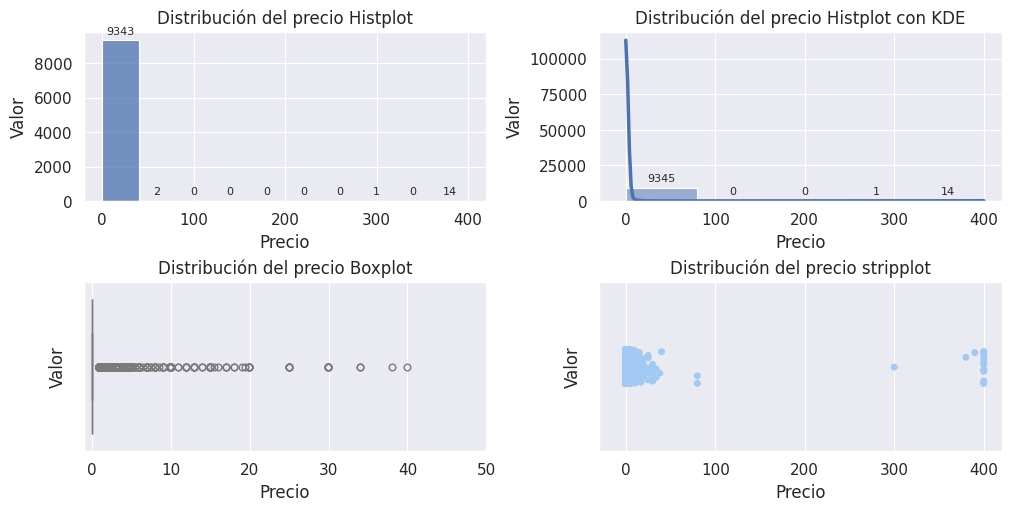

In [20]:
# Genera aquí el código para gráficar la distribución de la variable Price (sin filtrar los datos)
##### TAREA 2 #####################
# Configuración para usar tema, estilo darkgrid, tipo paper con escala letra 1.25 ancho de linea 2.5, paleta de colores pastel
sns.set_theme()
sns.set_style("darkgrid")
sns.set_context("paper", font_scale=1.25, rc={"lines.linewidth": 2.5})
sns.color_palette("pastel")

# Crear subplot, constrained para evitar superponer
plt.subplots(2,2,layout='constrained',figsize=(10,5))

# histplot del Precio
plt.subplot(2,2,1)
plt.title("Distribución del precio Histplot")
# Usamos 5 agrupaciones, porque tienen outliers separados que dificultan la visualización
precio_hist_fig=sns.histplot(x='Price',data=data, bins=10,palette='pastel')
plt.xlabel("Precio"), plt.ylabel("Valor")
# Mostrar Etiquetas en cada barra
precio_hist_fig.bar_label(precio_hist_fig.containers[0],fontsize=8,padding=3)

# histplot del Precio con KDE
plt.subplot(2,2,2)
plt.title("Distribución del precio Histplot con KDE")
# Usamos 5 agrupaciones, porque tienen outliers separados que dificultan la visualización
precio_hist_fig2=sns.histplot(x='Price',data=data, kde='True',bins=5,palette='pastel')
plt.xlabel("Precio"), plt.ylabel("Valor")
# Mostrar Etiquetas en cada barra
precio_hist_fig2.bar_label(precio_hist_fig2.containers[0],fontsize=8,padding=3)
plt.xlim(-30)

# boxplot del Precio
plt.subplot(2,2,3)
plt.title("Distribución del precio Boxplot")
# No se observan las cajas, porque los outliers son muy grandes
precio_box_fig3=sns.boxplot(data=data,x='Price', palette='pastel')
plt.xlabel("Precio"), plt.ylabel("Valor")
plt.xlim(-1,50)

# stripplot del Precio
plt.subplot(2,2,4)
plt.title("Distribución del precio stripplot")
# No se observan las cajas, porque los outliers son muy grandes
precio_box_fig3=sns.stripplot(data=data,x='Price', palette='pastel')
plt.xlabel("Precio"), plt.ylabel("Valor")
plt.xlim(-30)

#################################


In [22]:
# Calcula e imprime los valores inferiores y superiores del rango intercuartilico
# para las siguientes variables: Price
# No olvides que solo consideraremos las aplicaciones pagas (excluir las gratuitas)
#### TAREA 3 ###############
# Creamos un dataset con las aplicaciones que son pagadas, Tipo PAID y Price mayor a 0 USD
data_pago = data[(data.Type == 'Paid')& (data.Price > 0)]

print("\n"+"+"*80)
print (f'Se tienen { data_pago.shape[0]} aplicaciones pagadas.\n')

# Calculamos los rangos intercuartílicos
#Limite inferior
Q1 = data_pago['Price'].quantile(0.25)
#Limite superior
Q3 = data_pago['Price'].quantile(0.75)
IQR = Q3 - Q1
min_value = Q1 - 1.5 * IQR
max_value = Q3 + 1.5 * IQR


print(f"Valor inferior del rango intercuartílico de PRICE : {min_value}")
print(f"Valor Superior del rango intercuartílico de PRICE: {max_value}")
print("+"*80)
#############################


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Se tienen 645 aplicaciones pagadas.

Valor inferior del rango intercuartílico de PRICE : -2.51
Valor Superior del rango intercuartílico de PRICE: 9.49
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [23]:
# coloca el valor del máximo y minimo a filtrar para Price
# Nota: mira que estamos sobrescribiendo la variable data (esto con el fin de que todos obtengamos
# el mismo resultado)

#Comentamos las lineas de abajo porque ya las calculamos arriba
#min_value = -2.51
#max_value = 9.49

# Dataset limpio de outliers
print(f"Datos antes de la limpieza de outliers de PRICE: {data.shape[0]}")

data = data[(data.Price>=min_value) & (data.Price<=max_value)]

print(f"Datos después de la limpieza de outliers de PRICE: {data.shape[0]}")


Datos antes de la limpieza de outliers de PRICE: 9360
Datos después de la limpieza de outliers de PRICE: 9271


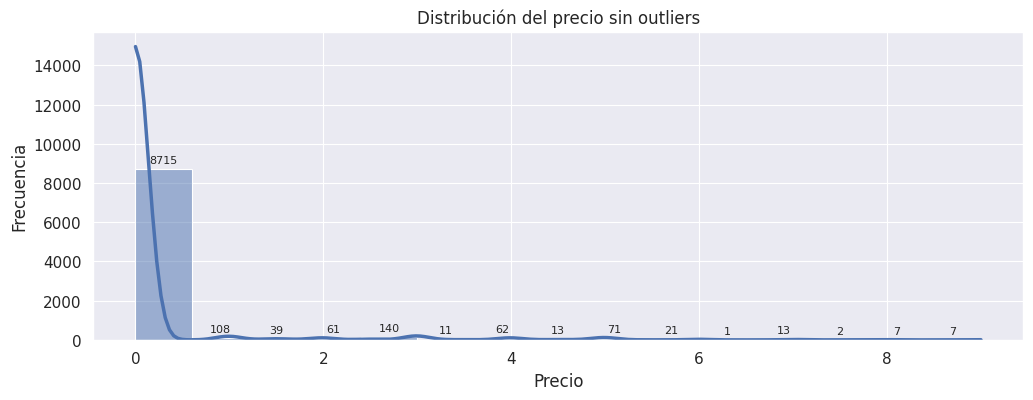

In [25]:
# Genera aquí el código para gráficar la distribución de la variable Price
##### TAREA 4 #####################

# histplot del Precio limpio de outliers
plt.figure(figsize=(12,4))
plt.title("Distribución del precio sin outliers")
# Usamos KDE  para ver la la distribución de probabilidad de los datos de PRICE
precio_histlimpio_fig=sns.histplot(data=data,x='Price', kde='True',palette='pastel')
plt.xlabel("Precio"), plt.ylabel("Frecuencia")
precio_histlimpio_fig.bar_label(precio_histlimpio_fig.containers[0],fontsize=8,padding=3);



Realicen el mismo procedimiento anterior pero ahora para las variables:


*   ```Reviews```
*   ```Installs```
*   ```Size```

**Nota**: recuerda, estamos filtrando outliers en base al rango intercuartílico.

In [26]:
# Calcula e imprime los valores inferiores y superiores del rango intercuartilico
# para las siguientes variables: Reviews
#### TAREA 5 ###############

# Calculamos los rangos intercuartílicos
#Limite inferior
Q1 = data['Reviews'].quantile(0.25)
#Limite superior
Q3 = data['Reviews'].quantile(0.75)
IQR = Q3 - Q1
min_val = Q1 - 1.5 * IQR
max_val = Q3 + 1.5 * IQR

print("\n"+"+"*80)
print("VARIABLE REVIEWS")
print(f"Valor inferior del rango intercuartilico de Reviews: {min_val}")
print(f"Valor Superior del rango intercuartilico de Reviews: {max_val}")
print("+"*80)

#############################


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
VARIABLE REVIEWS
Valor inferior del rango intercuartilico de Reviews: -125172.0
Valor Superior del rango intercuartilico de Reviews: 209140.0
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [27]:
# coloca el valor del máximo y minimo a filtrar para Reviews

# Comentamos las lineas porque se calcularon arriba
#min_val = #colocar valor minimo
#max_val = #colocar valor maximo

print("\n"+"+"*80)
print(f"Datos antes de la limpieza de outliers de REVIEWS: {data.shape[0]}")

# Filtramos los outliers con los rangos minimo y maximo
data = data[(data.Reviews>=min_val) & (data.Reviews<=max_val)]
print(f"Datos después de la limpieza de outliers de REVIEWS: {data.shape[0]}")

print("+"*80)



++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Datos antes de la limpieza de outliers de REVIEWS: 9271
Datos después de la limpieza de outliers de REVIEWS: 7656
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


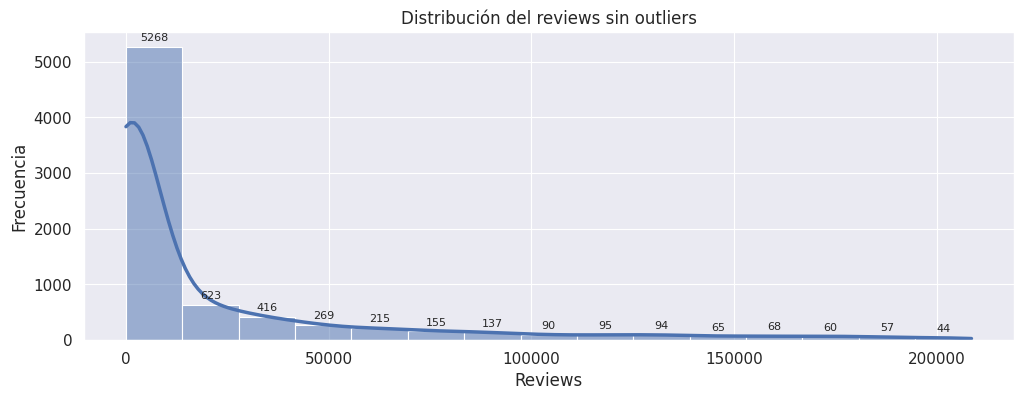

In [30]:
# Genera aquí el código para gráficar la distribución de la variable Reviews
##### TAREA 6 #####################

# histplot de REVIEWS sin outliers
plt.figure(figsize=(12,4))
plt.title("Distribución del reviews sin outliers")
# Usamos KDE  para ver la la distribución de probabilidad de los datos de REVIEWS
reviews_histlimpio_fig=sns.histplot(data=data,x='Reviews', kde='True', bins=15,palette='pastel')
plt.xlabel("Reviews"), plt.ylabel("Frecuencia")
reviews_histlimpio_fig.bar_label(reviews_histlimpio_fig.containers[0],fontsize=8,padding=3);


In [29]:
# Calcula e imprime los valores inferiores y superiores del rango intercuartilico
# para las siguientes variables: Installs
#### TAREA 7 ###############

# Calculamos los rangos intercuartílicos
#Limite inferior
Q1 = data['Installs'].quantile(0.25)
#Limite superior
Q3 = data['Installs'].quantile(0.75)
IQR = Q3 - Q1
min_val = Q1 - 1.5 * IQR
max_val = Q3 + 1.5 * IQR

print("\n"+"+"*80)
print("VARIABLE INSTALLS")
print(f"Valor inferior de Reviews: {min_val}")
print(f"Valor Superior de Reviews: {max_val}")
print("+"*80)


#############################


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
VARIABLE INSTALLS
Valor inferior de Reviews: -1475000.0
Valor Superior de Reviews: 2485000.0
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [31]:
# coloca el valor del máximo y minimo a filtrar para Installs
#Comentamos las lineas porque se calcularon arriba
#min_val = # colocar valor
#max_val = # colocar valor

print("\n"+"+"*80)
print(f"Datos antes de la limpieza de outliers de INSTALLS: {data.shape[0]}")

# Filtramos los outliers con los rangos minimo y maximo
data = data[(data.Installs>=min_val) & (data.Installs<=max_val)]
print(f"Datos después de la limpieza de outliers de INSTALLS: {data.shape[0]}")

print("+"*80)



++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Datos antes de la limpieza de outliers de INSTALLS: 7656
Datos después de la limpieza de outliers de INSTALLS: 6428
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


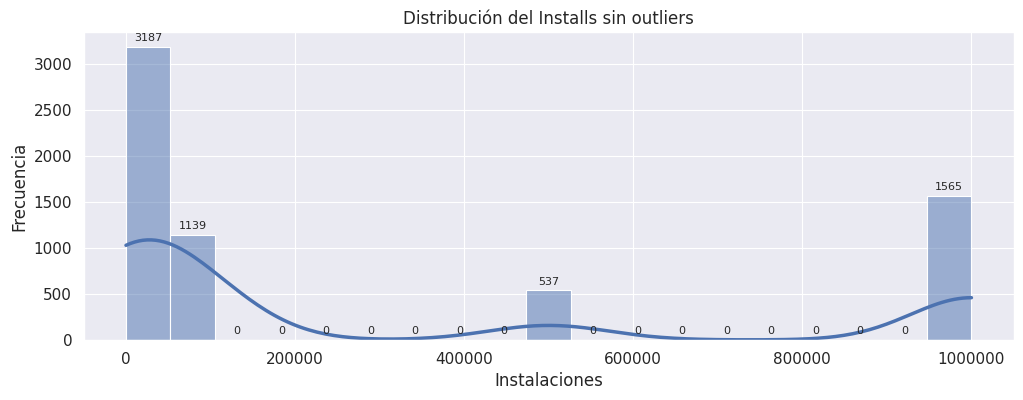

In [33]:
# Genera aquí el código para gráficar la distribución de la variable Installs
##### TAREA 8 #####################

import matplotlib.ticker as ticker


# histplot de INSTALLS sin outliers
plt.figure(figsize=(12,4))
plt.title("Distribución del Installs sin outliers")
# Usamos KDE  para ver la la distribución de probabilidad de los datos de INSTALLS
installs_histlimpio_fig=sns.histplot(data=data,x='Installs',kde='True', palette='pastel')

#Desactivar notacion exponencial
installs_histlimpio_fig.xaxis.set_major_formatter(ticker.ScalarFormatter())
installs_histlimpio_fig.ticklabel_format(style='plain', axis='x')

plt.xlabel("Instalaciones"), plt.ylabel("Frecuencia")
installs_histlimpio_fig.bar_label(installs_histlimpio_fig.containers[0],fontsize=8,padding=3);


In [36]:
# Calcula e imprime los valores inferiores y superiores del rango intercuartilico
# para las siguientes variables: Size
#### TAREA 9 ###############

# Calculamos los rangos intercuartílicos
#Limite inferior
Q1 = data['Size'].quantile(0.25)
#Limite superior
Q3 = data['Size'].quantile(0.75)
IQR = Q3 - Q1
min_val = Q1 - 1.5 * IQR
max_val = Q3 + 1.5 * IQR

print("\n"+"+"*80)
print("VARIABLE SIZE")
print(f"Valor inferior del rango intercuartilico de Reviews: {min_val}")
print(f"Valor Superior del rango intercuartilico de Reviews: {max_val}")
print("+"*80)


#############################


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
VARIABLE SIZE
Valor inferior del rango intercuartilico de Reviews: -21274.79428649535
Valor Superior del rango intercuartilico de Reviews: 47191.32381082559
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [39]:
# # coloca el valor del número a filtrar basado en la información del gráfico

#Comentamos las lineas porque se calcularon arriba
#min_val = # colocar valor
#max_val = # colocar valor


print("\n"+"+"*80)
print(f"Datos antes de la limpieza de outliers de SIZE: {data.shape[0]}")

# Filtramos los outliers con los rangos minimo y maximo
data = data[(data.Size>=min_val) & (data.Size<=max_val)]

print(f"Datos después de la limpieza de outliers de SIZE: {data.shape[0]}")

print("+"*80)




++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Datos antes de la limpieza de outliers de SIZE: 5815
Datos después de la limpieza de outliers de SIZE: 5815
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


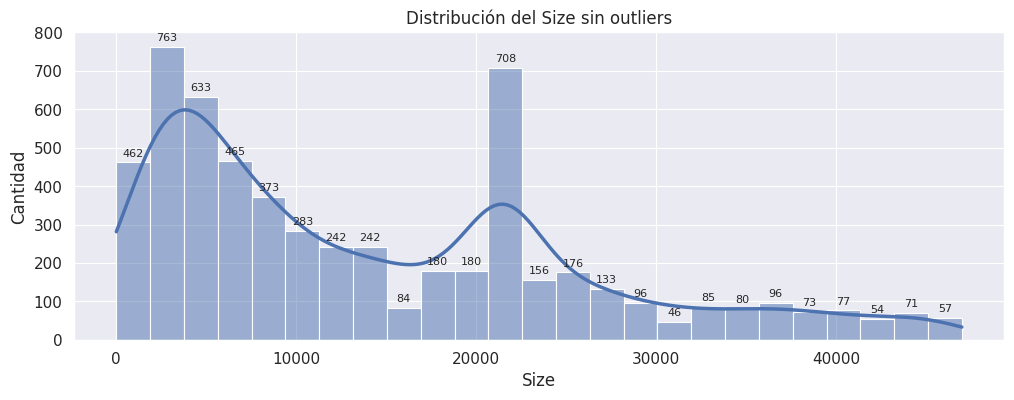

In [40]:
# Genera aquí el código para gráficar la distribución de la variable Size

# histplot de INSTALLS sin outliers
plt.figure(figsize=(12,4))
plt.title("Distribución del Size sin outliers")
# Usamos KDE  para ver la la distribución de probabilidad de los datos de INSTALLS
size_histlimpio_fig=sns.histplot(data=data,x='Size',kde='True', palette='pastel')

plt.xlabel("Size"), plt.ylabel("Cantidad")
size_histlimpio_fig.bar_label(size_histlimpio_fig.containers[0],fontsize=8,padding=3);

## Fase 2: Visualización de datos para soportar la toma de decisiones

Preferiblemente usar seaborn para las gráficas y matplotlib para la personalización en caso de ser necesario.

In [41]:
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800.0,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5600.0,50000,Free,0.0,Everyone,Art & Design,2017-03-26,1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19000.0,50000,Free,0.0,Everyone,Art & Design,2018-04-26,1.1,4.0.3 and up


En este punto deben iniciar a explorar las variables relevantes a las restricciones de la empresa. Es decir, importante relacionar la variable "Category" con columnas como "Price", "Rating", "Reviews", "Size" y "Installs". Piensen como cada columna se puede relacionar con las restriciones de la empresa.

Si no hay mucha claridad podemos hacer algunas visualizaciones generales. Por ejemplo identificar la relación entre el precio y las calificaciones. Será que aplicativos pagos y costosas tiene mejores reviews? Algo de esto podría servir para relacionar el orden de desarrollo de las aplicaciones con la rentabilidad a mediano plazo?

**Pregunta 4:** Qué gráfico puede usar para gráficar la relación entre precio y calificación?

RTA: Usamos un scatterplot.

**Pregunta 5:** Hay alguna relación importante?

RTA. No se observa ninguna relación importante. Independientemente del precio, pueden haber aplicaciones con muy pocas reviews. Solamente que las aplicaciones gratuitas pueden llegar a tener muchas reviews.

(Text(0.5, 0, 'Precio'), Text(0, 0.5, 'Calificaciones'))

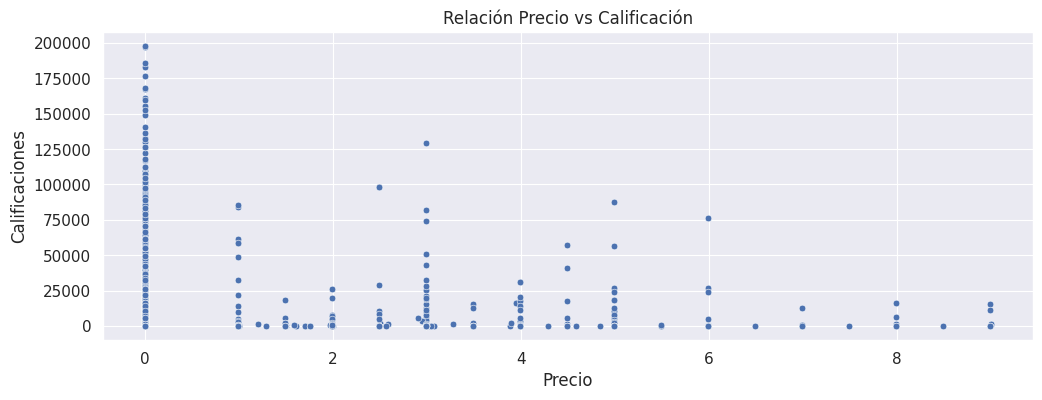

In [42]:
# Genera aquí el código para gráficar la relación entre las variables Precio y
# calificación

##### TAREA 10 #####################

plt.figure(figsize=(12,4))
plt.title("Relación Precio vs Calificación")
sns.scatterplot(data=data,x='Price', y='Reviews', palette='pastel')

plt.xlabel("Precio"), plt.ylabel("Calificaciones")


#############################

**Bonus**: Cuando se dispone de varias variables numéricas, la realización de múltiples gráficos de dispersión resulta bastante tediosa. Por lo tanto, se prefiere una visualización por pares en la que todos los diagramas de dispersión se encuentran en una única vista en forma de matriz.

Seabor permite esto fácilmente, tener en cuenta que:
*   Para las vistas no diagonales, se traza un diagrama de dispersión entre 2 variables numéricas.
*   Para las vistas diagonales, traza un histograma

In [44]:
?sns.pairplot

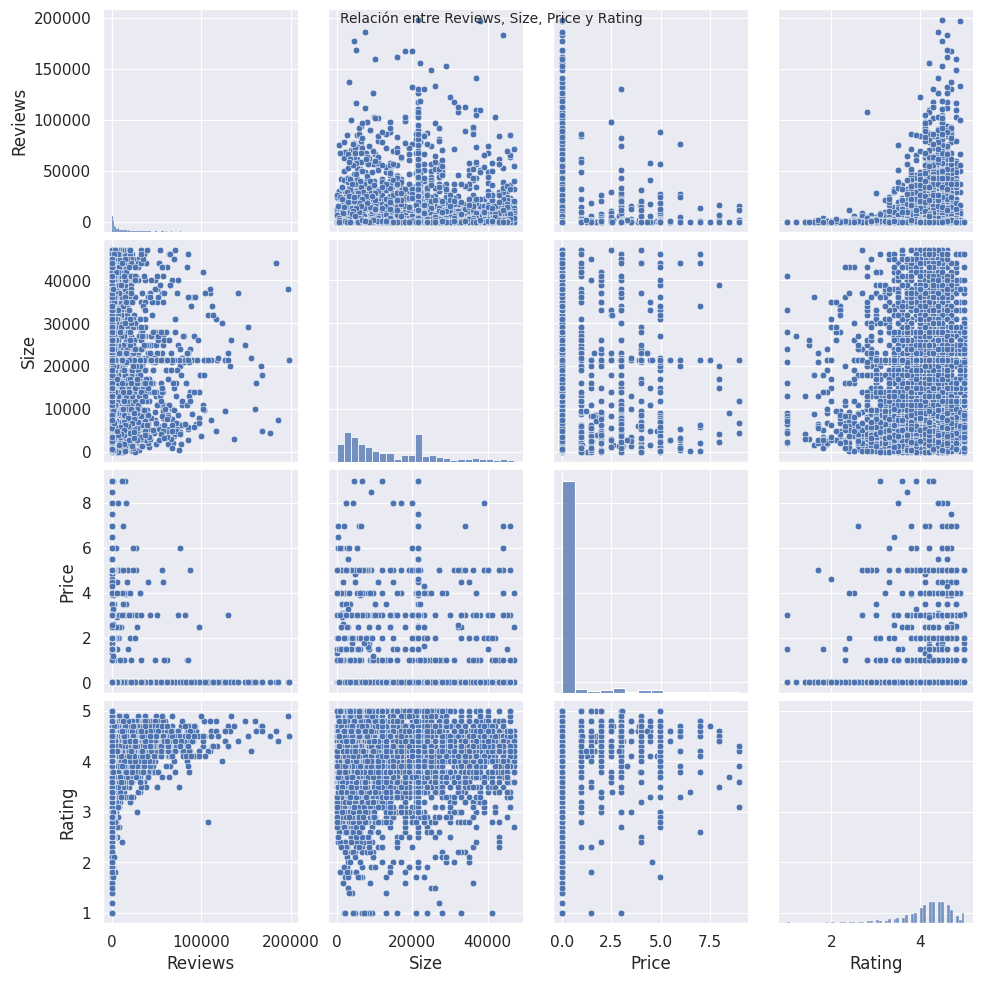

In [45]:
# filtrar los datos para que seaborn solo use las variables númericas que es desean
sns.pairplot(data[['Reviews', 'Size', 'Price','Rating']])
plt.suptitle('Relación entre Reviews, Size, Price y Rating', size=10)
plt.show()

Siguiendo con el análisis, sería de gran ayuda identificar la competencia que hay en la Google Store para cada categoría de las aplicaciones. Conocer la proporción de cada categoría nos podría indicar que sectores estan saturados de aplicativos. Qué crees?

**Pregunta 6:** Qué gráfico podriamos usar para visualizar esta proporción?

RTA: Un pie chart convertido en gráfico de dona para mejorar la visualización de las proporciones en porcentajes de las categorías

**Pregunta 7:** Dónde hay más competencia?, que porcentajes?

RTA: El top 5 de categorías serían los siguientes

- FAMILY   -  18.99%
- TOOLS   -    9.23%
- GAME    -    6.24%
- MEDICAL   -  4.97%
- FINANCE   -  4.44%

Por lo que se puede apreciar que la categoría más competitiva es la de aplicaciones familiares.

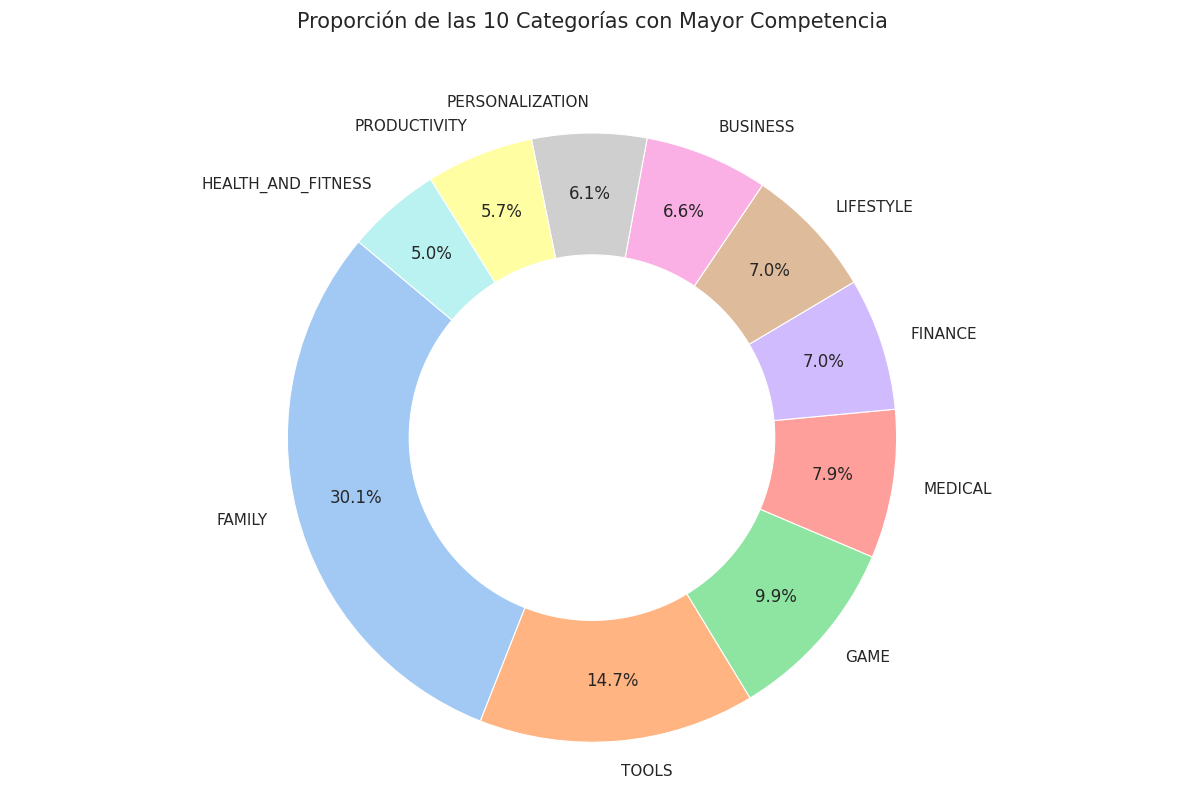

Top 5 Categorías con más competencia:
Category
FAMILY     18.985383
TOOLS       9.234738
GAME        6.242476
MEDICAL     4.969905
FINANCE     4.436801
Name: count, dtype: float64


In [52]:
# Genera aquí el código para gráficar la Proporción de las categorias de las
# aplicaciones en la Google Store

##### TAREA 11 #####################
# TU CÓDIGO AQUÍ
# Calcular la distribución de categorías
category_counts = data['Category'].value_counts()
# Seleccionamos las 10 principales para mayor claridad visual
top_categories = category_counts.head(10)

plt.figure(figsize=(12, 8))

plt.pie(top_categories,
        labels=top_categories.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'),
        pctdistance=0.80)

# Añadir un círculo blanco en el centro para hacer un gráfico de dona
centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Proporción de las 10 Categorías con Mayor Competencia', fontsize=15, y = 1.1)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Mostrar tabla de porcentajes para responder a la pregunta 7
proportions = (category_counts / len(data) * 100).head(5)
print("Top 5 Categorías con más competencia:")
print(proportions)

#############################

En este punto podemos continuar relacionando la variable categoría con las otras variables para seguir descubriendo elementos relevantes. Que tal si ahora, nos centramos en tratar de descrifrar como podemos medir la ganancia de reconocimiento rápidamente de las categorías? será que el número de instalaciones nos podría medir si esa categoría potencialmente puede ganar reconocimiento por la cantidad de instalaciones que tienen?

Por otro lado, vimos que aplicaciones gratuitas tienden a tener reviews más altos, para profundizar, podríamos revisar la relación que tiene el precio con las aplicaciones por categoría, nos daría esto indicios acerca de cual sector es más rentable o genera más ingresos?

**Pregunta 8:** Qué gráfico permite evidenciar cantidades en un conjunto de categorías?

RTA: En este caso utilizamos barplot para visualizar las cantidad de cada categorías

**Pregunta 9:** Cuál es la categoría con un número mayor de instalaciones y por cual categoría en promedio se paga un precio más alto?

RTA: La categoría FAMILY es la que presenta el mayor volumen de descargas, superando los 253 millones de instalaciones. Se identifica que el precio promedio más alto tiende a concentrarse en categorías específicas (como MEDICAL o WEATHER), contrastando con las categorías de consumo masivo que suelen ser gratuitas o de bajo costo como la categoría FAMILY o TOOLS.

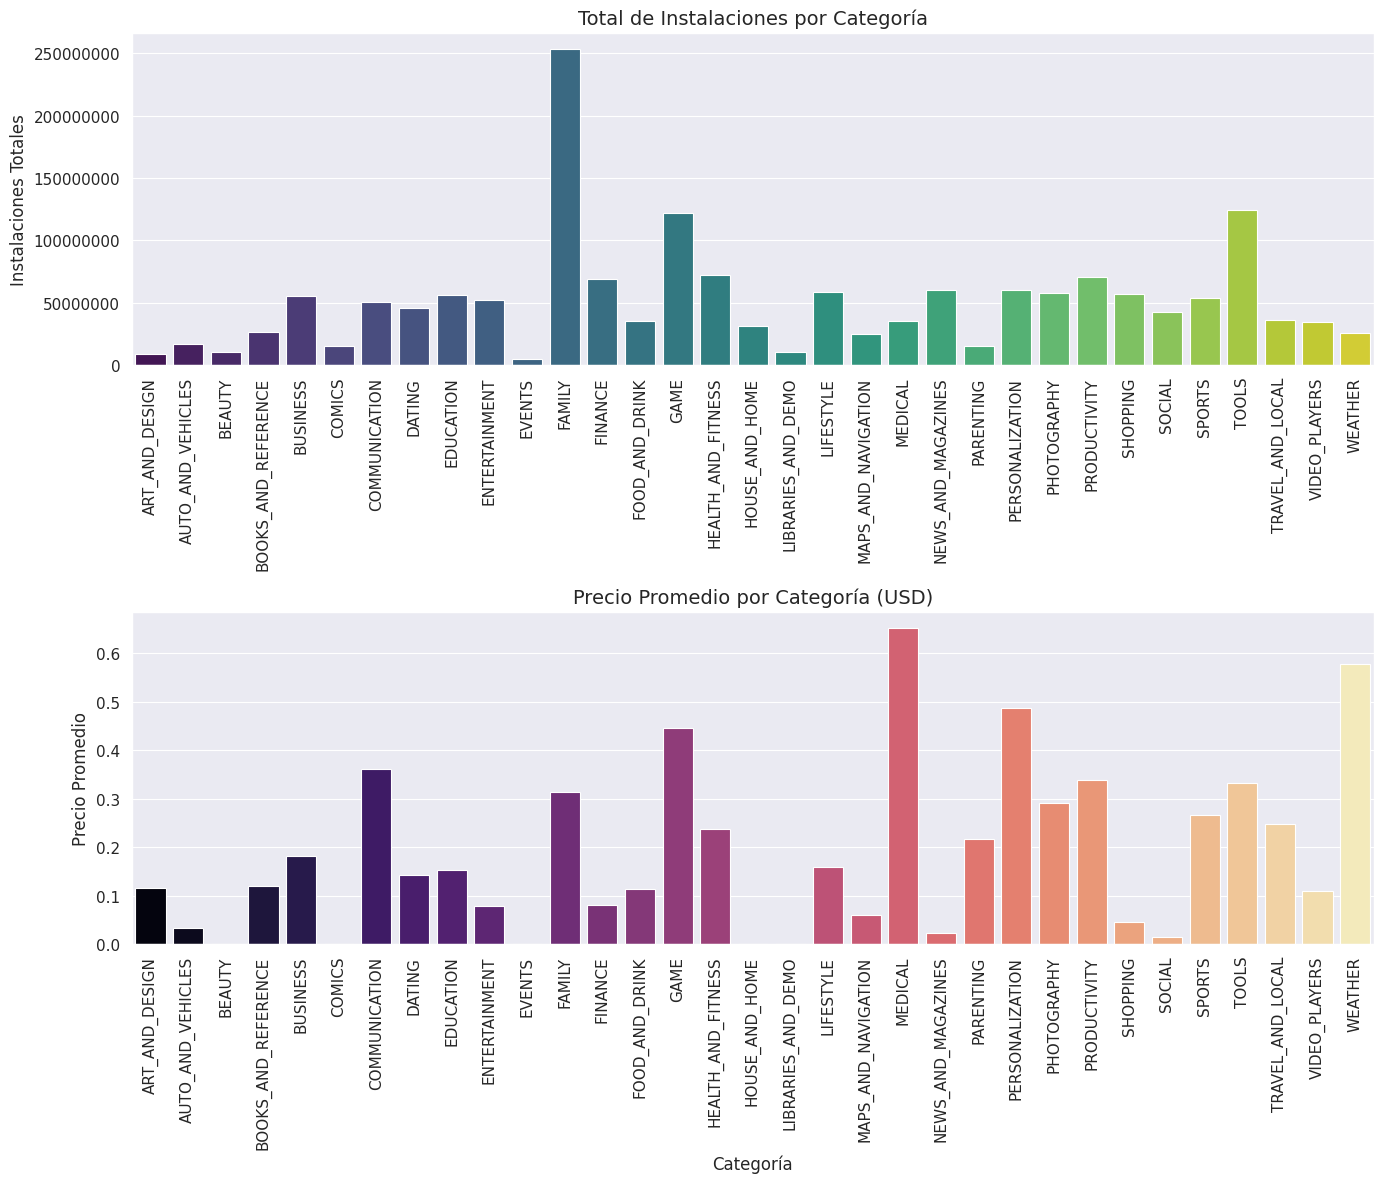

Resumen de Métricas por Categoría (Top 5 por Instalaciones):


,Category,Installs,Price
11,FAMILY,253734080,0.314339
29,TOOLS,124143400,0.331322
14,GAME,121802507,0.445179
15,HEALTH_AND_FITNESS,72233220,0.237104
25,PRODUCTIVITY,70968080,0.339330


In [61]:
# Genera aquí el código para gráficar la relación de cantidades con las categorías
# tanto de número total de instalaciones y precio promedio por categoría.

# en este punto para relacionar más fácilmente la información de las dos partes
# construir una figura en matplotlib con dos filas y una columna. En el lienzo 1
# grafica el número total de instalaciones por categoría y en el lienzo 2
# grafica el precio promedio por categoría

# hint: Para crear el gráfico de dos filas y una columna usen plt.subplots
# y luego envien cada lienzo como parámetro a la grafica de seaborn de esta manera:
# sns.graficoausar(....., ax=axes[0])

# Usen pandas para generar el conteo total de número de instalaciones y
# promedio por categorías usando la función groupby despues gráfica esta
# información con seaborn

##### TAREA 12 #####################
# TU CÓDIGO AQUÍ

# Agrupar datos por categoría y calcular métricas
category_metrics = data.groupby('Category').agg({
    'Installs': 'sum',
    'Price': 'mean'
}).reset_index()

# Configurar la figura con 2 filas y 1 columna
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Primer subplot: Total de Instalaciones por Categoría
plot_inst_per_cat = sns.barplot(data=category_metrics, x='Category', y='Installs', ax=axes[0], palette='viridis', hue='Category', legend=False)

#Eliminamos la notación científica en el eje y del numero de las instalaciones
plot_inst_per_cat.ticklabel_format(style='plain', axis='y')
axes[0].set_title('Total de Instalaciones por Categoría', fontsize=14)
axes[0].set_xlabel('')
axes[0].set_ylabel('Instalaciones Totales')
axes[0].tick_params(axis='x', rotation=90)

# Segundo subplot: Precio Promedio por Categoría
sns.barplot(data=category_metrics, x='Category', y='Price', ax=axes[1], palette='magma', hue='Category', legend=False)
axes[1].set_title('Precio Promedio por Categoría (USD)', fontsize=14)
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Precio Promedio')
axes[1].tick_params(axis='x', rotation=90)


plt.tight_layout()
plt.show()

# Mostrar resultados numéricos
print('Resumen de Métricas por Categoría (Top 5 por Instalaciones):')
display(category_metrics.sort_values(by='Installs', ascending=False).head(5))


En este punto deberíamos tener un poco más claro cual aplicación debería desarrollarse primero. Sin embargo, podemos analizar aspectos como desarrollo rápido del tipo de aplicación, ya que la empresa no cuenta con un amplio personal de desarrollo. Crees que el tamño del aplicativo "size" nos puede servir como criterio para decidir si una aplicación se puede desarrollar rápidamente, sin la necesidad de varios desarrolladores? Además, de manera similar podríamos pensar que la distribución de rating por categoría me puede brindar información de cuáles sectores tienen mayor exigencia en la calidad de las aplicaciones desarrolladas, Crees que la experiencia de algunos desarrolladores en el sector productivo nos da una ventaja en este sentido?


**Pregunta 10:** Qué gráficos son adecuados para visualizar estas distribuciones de manera detallada? Cómo podemos comparar las distribuciones?

RTA: Los gráficos más adecuados son el Boxplot con stripplot para ver puntos individuales y el Violin Plot.

- El Boxplot nos permite comparar rápidamente las medianas y la dispersión (IQR) de los tamaños.
- El Violin Plot es superior para el Rating porque muestra la densidad, permitiendo ver qué tan estrictos son los usuarios en cada sector.

**Pregunta 11:** Qué categoría tiene en promedio un tamaño de app mayor? cuál categoría presenta un sector más exigente?

- La categoría con mayor tamaño es GAME lidera con un promedio de 23.7 MB, lo que indica una mayor complejidad de código y desarrollo.
- El sector más exigente es MEDICAL presenta la calificación promedio más alta (4.17) y a la cez una distribución de densidad más estrecha en la parte superior, sugiriendo que los usuarios esperan un estándar de calidad muy alto en esta categoría.

**hint:** Solo compara las categorías de interés: "PRODUCTIVITY", "MEDICAL", "GAME"

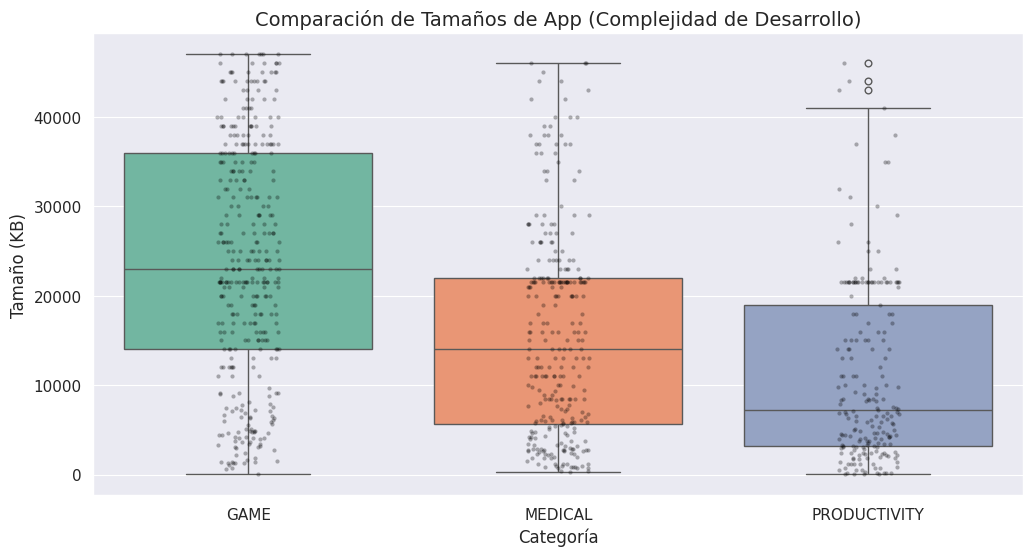

In [62]:
# Genera aquí el código para comparar las distribuciones del tamaño en las 3
# categorias de interés: 'PRODUCTIVITY', 'MEDICAL', 'GAME'

##### TAREA 13 #####################
# TU CÓDIGO AQUÍ

# Filtrar solo las categorías de interés
categorias_interes = ['PRODUCTIVITY', 'MEDICAL', 'GAME']
data_filtrada = data[data['Category'].isin(categorias_interes)]

# Visualización de la distribución de Size
plt.figure(figsize=(12, 6))
sns.boxplot(data=data_filtrada, x='Category', y='Size', palette='Set2', hue='Category', legend=False)
sns.stripplot(data=data_filtrada, x='Category', y='Size', color='black', alpha=0.3, size=3)

plt.title('Comparación de Tamaños de App (Complejidad de Desarrollo)', fontsize=14)
plt.xlabel('Categoría')
plt.ylabel('Tamaño (KB)')
plt.show()


#############################

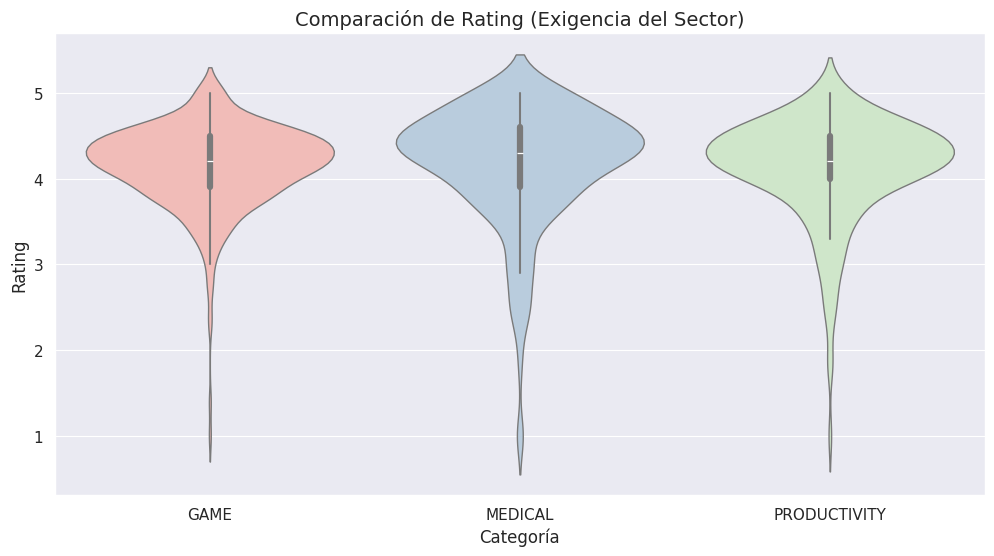

Estadísticas de Size y Rating por Categoría:


,Category,Size,Rating
0,GAME,23699.807656,4.150689
1,MEDICAL,15666.670476,4.174394
2,PRODUCTIVITY,11049.180989,4.126794


In [65]:
# Genera aquí el código para comparar las distribuciones del rating en las 3
# categorias de interés: 'PRODUCTIVITY', 'MEDICAL', 'GAME'

##### TAREA 14 #####################
# TU CÓDIGO AQUÍ

# Visualización de la distribución de Rating
plt.figure(figsize=(12, 6))
sns.violinplot(data=data_filtrada, x='Category', y='Rating', palette='Pastel1', hue='Category', legend=False)

plt.title('Comparación de Rating (Exigencia del Sector)', fontsize=14)
plt.xlabel('Categoría')
plt.ylabel('Rating')
plt.show()

# Resumen estadístico para responder la Pregunta 11
resumen_final = data_filtrada.groupby('Category').agg({'Size': 'mean', 'Rating': 'mean'}).reset_index()
print("Estadísticas de Size y Rating por Categoría:")
display(resumen_final)

#############################

## Fase 3: Conclusiones y sugerencias finales

Llegamos al final de nuestro análisis, como vimos se intentó relacionar la categoría a la que pertenecen las aplicaciones en el roadmap con variables que nos pueden ayudar a cumplir las restricciones de la compañía, resumen:


1.   Cantidad de aplicaciones en la google store por categoría para cuantificar la competencia en cada sector.
2.   Cantidad de instalaciones de las app por categoría para abordar un posible crecimiento portencial o popularidad de las apps en cada categoría.
3. Precio promedio de pago por las apps en cada categoría para evaluar la rentabilidad en cada sector.
4. Tamaño de las apps por sector para evaluar la cantidad de recurso humano necesario para salir al mercado con una versión.
5. Rating por categoría como forma de evaluar la exigencia del sector y aprovechar la experiencia del equipo.

**Pregunta 12:** Cuál es el orden que van a proponer a los líderes de la empresa? qué sistema de calificación o criterios usaron para fijar ese orden?

RTA: Basado en el análisis realizado en este trabajo, proponemos el siguiente orden de desarrollo para la empresa:

### 1. **PRODUCTIVITY**
*   **Eficiencia de Recursos**. Presenta el tamaño promedio más bajo (~11 MB), lo que permite un desarrollo rápido. Además, tiene una competencia moderada y un buen volumen de instalaciones, ideal para generar interés temprano.

### 2. **MEDICAL**
*   **Rentabilidad Premium**. Aunque el sector es altamente exigente (Rating 4.17), ofrece una menor saturación de mercado y la posibilidad de precios promedio más altos. Es ideal para aprovechar sectores de alta calidad una vez la empresa se encuentre establecida.

### 3. **GAME**
*   **Alcance Masivo a Largo Plazo**. A pesar de tener el mayor potencial de instalaciones, su complejidad técnica es la más alta (Size > 23 MB) y el mercado está muy saturado. Se recomienda una vez que la empresa cuente con más personal de desarrollo con mayor experiencia en tecnologías para el desarrollo de videojuegos.

**Sistema de Calificación Utilizado:**
Se aplicaron 3 criterios:
1.  **Time-to-Market** (Menor tamaño = Desarrollo más rápido).
2.  **Oportunidad de Nicho** (Menor competencia en categorías especializadas).
3.  **Calidad de Desarrollo** (Aprovechamiento de la experiencia en sectores con alta valoración).